Please pip install geopandas, osmnx, folium, contextily, requests individually if not available 

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point
from pathlib import Path
import requests
import json

## Get the Secondary Schools in Bradford

In [2]:
# Query overpass API
query = """
[out:json][timeout:90];
area["name"="Bradford"]["boundary"="administrative"]["admin_level"="8"]["ISO3166-2"="GB-BRD"]->.searchArea;
(
  node["amenity"="school"](area.searchArea);
  way["amenity"="school"](area.searchArea);
  relation["amenity"="school"](area.searchArea);
);
out center tags;
"""

This next chunk could display error/warning when you run it. This because it could disengage within the time frame. Rerun it two or three times immediately.

In [3]:
url = "https://overpass-api.de/api/interpreter"
response = requests.get(url, params={"data": query})
data = response.json()

In [4]:
# Select the features for the data collection
schools_df = pd.json_normalize(data["elements"])

In [5]:
# View the columns
schools_df.columns

Index(['type', 'id', 'lat', 'lon', 'tags.amenity', 'tags.name',
       'tags.addr:city', 'tags.addr:postcode', 'tags.addr:street',
       'tags.capacity', 'tags.check_date', 'tags.fhrs:id', 'tags.isced:level',
       'tags.max_age', 'tags.min_age', 'tags.phone', 'tags.ref:GB:uprn',
       'tags.ref:edubase', 'tags.school:type', 'tags.website', 'tags.source',
       'tags.operator', 'tags.operator:type', 'tags.operator:wikidata',
       'tags.ref:edubase:group', 'tags.school:group:type', 'tags.leisure',
       'tags.note', 'tags.school', 'center.lat', 'center.lon',
       'tags.addr:district', 'tags.source:addr', 'tags.wikidata',
       'tags.addr:suburb', 'tags.denomination', 'tags.diocese',
       'tags.religion', 'tags.source:addr:postcode', 'tags.addr:village',
       'tags.school:boarding', 'tags.school:gender', 'tags.school:selective',
       'tags.old_name', 'tags.addr:country', 'tags.email', 'tags.wikipedia',
       'tags.official_name', 'tags.addr:housenumber', 'tags.fixme:addr

Only node provides latitute and longitude, while way and relation gives as center.lon and center.lat.  I will fill the emplty longitude and latitude with the center.lat and center.lon.

In [6]:
# Fix ways and relations store coordinates in center.lat / center.lon
schools_df["lat"] = schools_df["lat"].fillna(schools_df["center.lat"])
schools_df["lon"] = schools_df["lon"].fillna(schools_df["center.lon"])

Select the columns that are necessary for the work.

In [7]:
# Select the needed coluns
schools_df = schools_df[['id', 'tags.name', 'tags.addr:street', 'lat', 'lon',
                         'type', 'tags.isced:level', 'tags.school']]

schools_df.columns

Index(['id', 'tags.name', 'tags.addr:street', 'lat', 'lon', 'type',
       'tags.isced:level', 'tags.school'],
      dtype='object')

In [8]:
# Rename the columns
schools_df = schools_df.rename(columns={
    "id": "osm_id",
    "type": "osm_type",
    "tags.name": "school_name",
    "tags.school": "school_type",
    "tags.isced:level": "isced_level",
    'tags.addr:street': 'street_address',
    'lat': 'latitude',
    'lon': 'longitude'
})

In [9]:
schools_df.head()

,osm_id,school_name,street_address,latitude,longitude,osm_type,isced_level,school_type
0,685938868,Branches @ Carrwood Community & Family Skills ...,NaN,53.780554,-1.706121,node,NaN,NaN
1,777472163,Lady Lane Park School & Nursery,College Road,53.860661,-1.830224,node,0;1,NaN
2,1244326064,Challenge CLC,NaN,53.815367,-1.765478,node,NaN,NaN
3,1633801242,Haycliffe School,NaN,53.773542,-1.779614,node,NaN,NaN
4,3954682148,Hazelbeck Special School,Wagon Lane,53.841401,-1.827540,node,2;3,NaN


In [10]:
# Save the school data
schools_df.to_csv('bradford_schools.csv')

An ISCED (International Standard Classification of Education) level is the UNESCO framework which categorses education systems and qualifications into standardised levels. It ranges from level 0-8, where:
1. ISCED 0: Early childhood education.
2. ISCED 1: Primary education.
3. ISCED 2: Lower secondary education.
4. ISCED 3: Upper secondary education.
5. ISCED 4: Post-secondary non-tertiary education.
6. ISCED 5: Short-cycle tertiary education.
7. ISCED 6: Bachelor’s or equivalent level.
8. ISCED 7: Master’s or equivalent level.
9. ISCED 8: Doctoral or equivalent level.

Since our analysis is aimed at secondary schools, ISCED levels 2 and 3 will be aimed. A number of the schools do not have the these indicated as well, hence I can look for where the names contain secondary.

In [11]:
# Filter for only the secondary schools
secondary_df = schools_df[
    schools_df['school_name'].str.contains("secondary", case=False, na=False) |
    schools_df["isced_level"].str.contains("2|3", na=False)
].copy()

In [12]:
secondary_df.to_csv('bradford_secondary_schools.csv')

## Load in the crime data

In [13]:
# Use glob to point to directory where the files live
path = glob.glob("C:/Users/xqbp417/Desktop/Crime and Education project/*-west-yorkshire-street.csv")

In [14]:
# Create an empty frame
crime_df = []

# read in the data and append to the empty frame
for file in path:
    crime = pd.read_csv(file)
    crime_df.append(crime)

In [15]:
# Merge the datasets longitudinally
crime_df = pd.concat(crime_df, ignore_index=True)
crime_df

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,c4e113322794b27396dd1c6c88ace5b01afaa363a54125...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.459649,53.605743,On or near Bleakley Lane,E01007438,Barnsley 001C,Drugs,Local resolution,NaN
1,NaN,2023-03,West Yorkshire Police,West Yorkshire Police,-1.906708,53.939023,On or near Turner Lane,E01010646,Bradford 001A,Anti-social behaviour,NaN,NaN
2,7c83c08291e705d2b53df1b4fd5b22d910e247c805b662...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.881027,53.943719,On or near Main Street,E01010646,Bradford 001A,Criminal damage and arson,Investigation complete; no suspect identified,NaN
3,e170228bffc479e50fd542f26444e19f9d04bcb74bfcd1...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.879954,53.945857,On or near Aynholme Close,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
4,1b04ccf93c40b7da0d909094615d473685d00ca729f3bb...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.879954,53.945857,On or near Aynholme Close,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
931684,17446a77ea1f2ee607f00bf8500936dd1aa576a52ae85d...,2026-02,West Yorkshire Police,West Yorkshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Under investigation,NaN
931685,ce48f466a07d9961bd45d06bbf78b139626e2725f882f6...,2026-02,West Yorkshire Police,West Yorkshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Under investigation,NaN
931686,880f248c10f8fb4f6ee835256a617bc42285baaeef2bd2...,2026-02,West Yorkshire Police,West Yorkshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Under investigation,NaN
931687,6d203f0b8442d42b6be9e2d4af60d09f607fee91e442cb...,2026-02,West Yorkshire Police,West Yorkshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Under investigation,NaN


In [16]:
crime_df.columns

Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='object')

In [17]:
crime_df.isnull().sum()

Crime ID                  83360
Month                         0
Reported by                   0
Falls within                  0
Longitude                 10117
Latitude                  10117
Location                      0
LSOA code                 10117
LSOA name                 10117
Crime type                    0
Last outcome category     83360
Context                  931689
dtype: int64

In [18]:
crime_df['Longitude'].nunique()

34837

In [19]:
crimetype = crime_df["Crime type"].value_counts().reset_index()
crimetype.columns = ["Crime type", "count"]

# Data Cleaning

Convert the geometry points to geopandas.

In [22]:
# Convert the secondary school data
sec_df = gpd.GeoDataFrame(
    secondary_df, geometry = gpd.points_from_xy(
        secondary_df['longitude'], secondary_df['latitude'])
)

In [23]:
sec_df

,osm_id,school_name,street_address,latitude,longitude,osm_type,isced_level,school_type,geometry
4,3954682148,Hazelbeck Special School,Wagon Lane,53.841401,-1.827540,node,2;3,NaN,POINT (-1.82754 53.8414)
7,12272261462,Dixons Trinity Academy,NaN,53.786414,-1.761281,node,2,secondary,POINT (-1.76128 53.78641)
13,27430004,Carlton Bolling,Undercliffe Lane,53.802248,-1.738203,way,2,secondary,POINT (-1.7382 53.80225)
14,27430869,Bradford Academy,Teasdale Street,53.776937,-1.732226,way,0;1;2;3,primary;secondary,POINT (-1.73223 53.77694)
15,27439679,Co-op Academy Grange,Haycliffe Lane,53.775439,-1.777453,way,2,secondary,POINT (-1.77745 53.77544)
36,51143176,Titus Salt School,Higher Coach Road,53.842914,-1.794062,way,2;3,secondary,POINT (-1.79406 53.84291)
37,51143343,Beckfoot School,Wagon Lane,53.840648,-1.828242,way,2;3,secondary,POINT (-1.82824 53.84065)
48,72765400,Jaamiatul Imaam Muhammad Zakaria,Thornton View Road,53.775754,-1.812779,way,2;3,NaN,POINT (-1.81278 53.77575)
56,144176269,Immanuel College,Leeds Road,53.842611,-1.726903,way,2;3,secondary,POINT (-1.7269 53.84261)
64,170627438,Ilkley Grammar School,Cowpasture Road,53.922108,-1.814690,way,2;3,secondary,POINT (-1.81469 53.92211)


In [37]:
# Convert the secondary school data
crime_df = gpd.GeoDataFrame(
    crime_df, geometry = gpd.points_from_xy(
        crime_df['Longitude'], crime_df['Latitude']),
    crs="EPSG:4326"
)

In [38]:
crime_df

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,geometry
0,c4e113322794b27396dd1c6c88ace5b01afaa363a54125...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.459649,53.605743,On or near Bleakley Lane,E01007438,Barnsley 001C,Drugs,Local resolution,NaN,POINT (-1.45965 53.60574)
1,NaN,2023-03,West Yorkshire Police,West Yorkshire Police,-1.906708,53.939023,On or near Turner Lane,E01010646,Bradford 001A,Anti-social behaviour,NaN,NaN,POINT (-1.90671 53.93902)
2,7c83c08291e705d2b53df1b4fd5b22d910e247c805b662...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.881027,53.943719,On or near Main Street,E01010646,Bradford 001A,Criminal damage and arson,Investigation complete; no suspect identified,NaN,POINT (-1.88103 53.94372)
3,e170228bffc479e50fd542f26444e19f9d04bcb74bfcd1...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.879954,53.945857,On or near Aynholme Close,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN,POINT (-1.87995 53.94586)
4,1b04ccf93c40b7da0d909094615d473685d00ca729f3bb...,2023-03,West Yorkshire Police,West Yorkshire Police,-1.879954,53.945857,On or near Aynholme Close,E01010646,Bradford 001A,Violence and sexual offences,Unable to prosecute suspect,NaN,POINT (-1.87995 53.94586)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
931684,17446a77ea1f2ee607f00bf8500936dd1aa576a52ae85d...,2026-02,West Yorkshire Police,West Yorkshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Under investigation,NaN,POINT (NaN NaN)
931685,ce48f466a07d9961bd45d06bbf78b139626e2725f882f6...,2026-02,West Yorkshire Police,West Yorkshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Under investigation,NaN,POINT (NaN NaN)
931686,880f248c10f8fb4f6ee835256a617bc42285baaeef2bd2...,2026-02,West Yorkshire Police,West Yorkshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Under investigation,NaN,POINT (NaN NaN)
931687,6d203f0b8442d42b6be9e2d4af60d09f607fee91e442cb...,2026-02,West Yorkshire Police,West Yorkshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Under investigation,NaN,POINT (NaN NaN)


In [34]:
bradford = gpd.read_file('2516.geojson')
bradford

,geometry
0,"POLYGON ((-1.8813 53.96309, -1.88042 53.96298,..."


<Axes: >

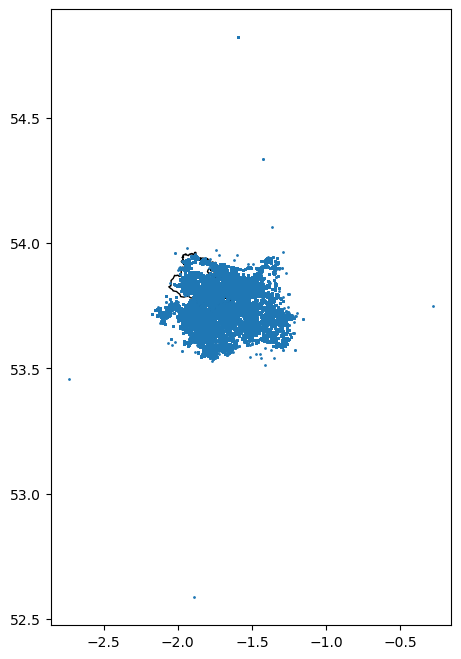

In [39]:
ax = bradford.to_crs("EPSG:4326").plot(figsize=(8, 8), edgecolor="black", facecolor="none")
crime_df.plot(ax=ax, markersize=1)